In [1]:
import sys

sys.path.append("..")  # Adds higher directory to python modules path.
import os
from src import RASPRoutines

RASP = RASPRoutines.RASP_Routines()

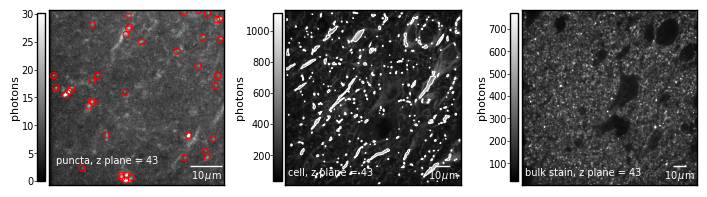

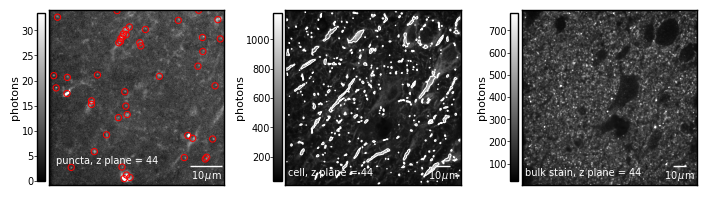

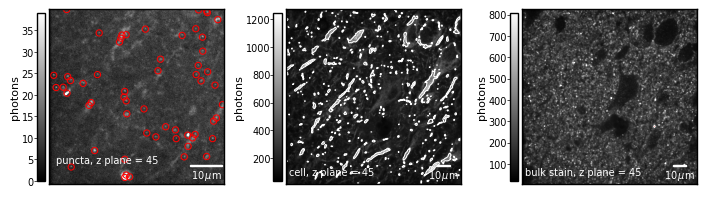

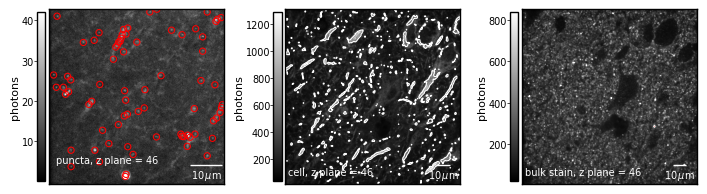

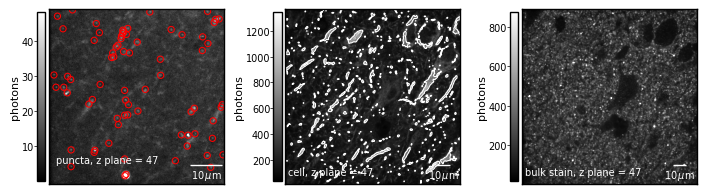

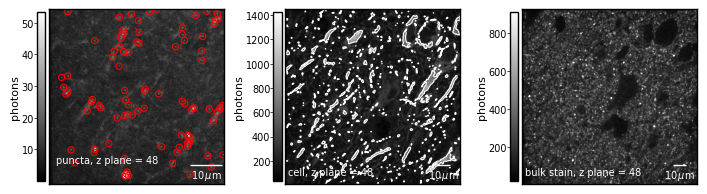

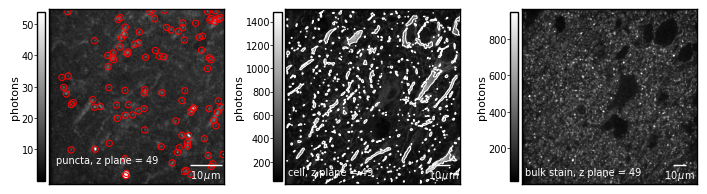

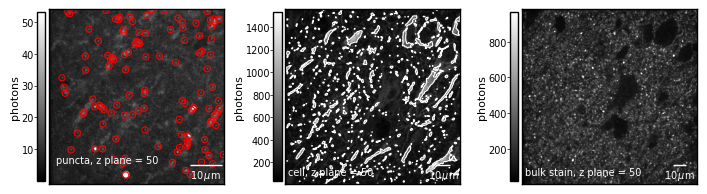

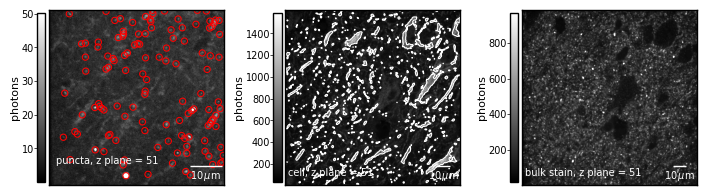

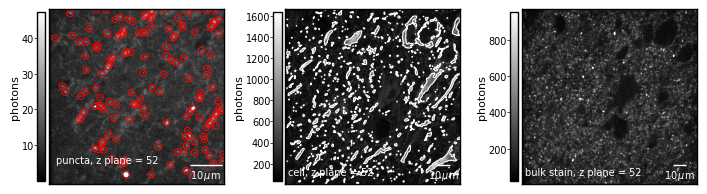

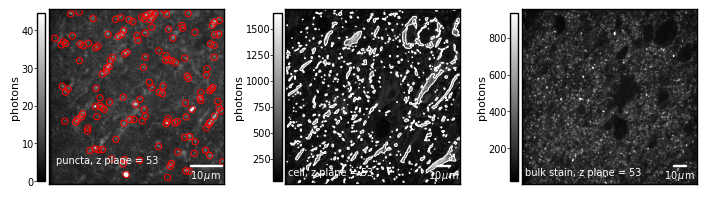

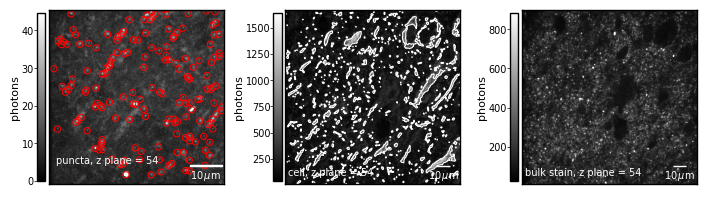

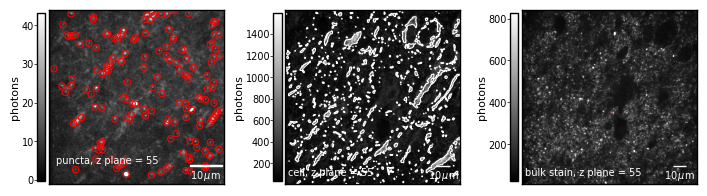

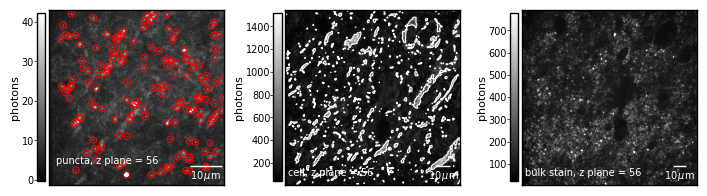

In [4]:
"""This notebook tunes the two new parameters needed for the three-colour
(oligomer + cell + bulk stain) pipeline, on a single test image, before
running the full folder analysis in Step3_ImageFolderAnalysis.ipynb.

Radiality (flatness/integratedGrad) is assumed already calibrated via
Step1_RadialityCalibration.ipynb (also copied into this folder).

Step A below tunes the bulk-stain threshold: RASP.bulk_threshold (and, if
needed, RASP.bulk_sigma1/RASP.bulk_sigma2) controls how the bulk stain
channel is thresholded into a binary mask (same difference-of-Gaussians
detector already used for cell/large-object masks, just a single threshold).
The plot below shows the raw bulk image with the resulting mask as a
semi-transparent overlay -- adjust RASP.bulk_threshold and re-run until the
mask tracks the bulk-stained regions you expect.

These values persist as attributes on RASP, so whatever you set here is
picked up automatically by RASP.analyse_images(..., bulk_string=...) in
Step3 -- no need to pass them again.

A cell_file is also passed below with test_cell_detection=False and
focus_images="C640" (the channel substring identifying cell_file below --
adjust if your cell channel uses a different label): this uses the cell
channel only to pick the in-focus z range (usually more reliable than the
sparser oligomer channel), without running or plotting cell mask detection
-- that's tuned separately in Step B below.
"""

RASP.bulk_threshold = 100.0  # tune this
# RASP.bulk_sigma1 = 2.0     # rarely needs changing
# RASP.bulk_sigma2 = 60.0    # rarely needs changing

folder = '/scratch/sycamore-asap/ASAP_Imaging_Data/Louise/20260716_testPDUK/slide7/ROI1'
protein_file = os.path.abspath(
    os.path.join(folder, "slide7_640_50ms-561-488_100ms_3x3roi_step250nm_1 - Position 1 [9]_XY1784188645_Z00_T0_C561.tif")
)  # example file, replace as you wish. Always input as the absolute path of a raw string
bulk_file = os.path.abspath(
    os.path.join(folder, "slide7_640_50ms-561-488_100ms_3x3roi_step250nm_1 - Position 1 [9]_XY1784188645_Z00_T0_C488.tif")
)  
cell_file = os.path.abspath(
    os.path.join(folder, "slide7_640_50ms-561-488_100ms_3x3roi_step250nm_1 - Position 1 [9]_XY1784188645_Z00_T0_C640.tif")
)  

RASP.single_image_analysis(
    protein_file,
    thres=0.05,
    large_thres=250.0,
    gsigma=1.4,
    rwave=2.0,
    image_size=500,
    save_figure=False,
    cell_file=cell_file,
    test_cell_detection=False,  # cell mask detection/plotting is tuned separately in Step B below
    bulk_file=bulk_file,
    focus_images="C640",  # channel substring matching cell_file, used to pick the in-focus z range
)

In [ ]:
"""Step B: tune the cell-detection parameters, the same way as in the
two-colour pipeline (example_twocolour_notebooks/Step2_SingleImageAnalysis.ipynb).

RASP.cell_threshold1 / RASP.cell_threshold2 / RASP.cell_sigma1 /
RASP.cell_sigma2 control the cell mask detector. The plot below shows the
raw cell image with the resulting mask drawn as a contour border -- adjust
and re-run until the outline matches the cells you expect.

These also persist as attributes on RASP and are picked up automatically by
RASP.analyse_images(..., cell_string=..., cell_analysis=True) in Step3.

focus_images="C0" below (the channel substring identifying cell_file) keeps
this cell looking at the cell channel for focus, consistent with Step A.
"""

RASP.cell_threshold1 = 200.0  # tune this
RASP.cell_threshold2 = 200.0  # tune this
# RASP.cell_sigma1 = 2.0      # rarely needs changing
# RASP.cell_sigma2 = 40.0     # rarely needs changing

protein_file = os.path.abspath(
    r"../example_images/Example_01_ProteinImage_C1.tif"
)  # example file, replace as you wish. Always input as the absolute path of a raw string
cell_file = os.path.abspath(
    r"../example_images/Example_01_CellImage_C0.tif"
)  # example file, replace as you wish. Always input as the absolute path of a raw string

RASP.single_image_analysis(
    protein_file,
    thres=0.05,
    large_thres=250.0,
    gsigma=1.4,
    rwave=2.0,
    image_size=500,
    save_figure=False,
    cell_file=cell_file,
    bulk_file=None,
    focus_images="C0",  # channel substring matching cell_file
)